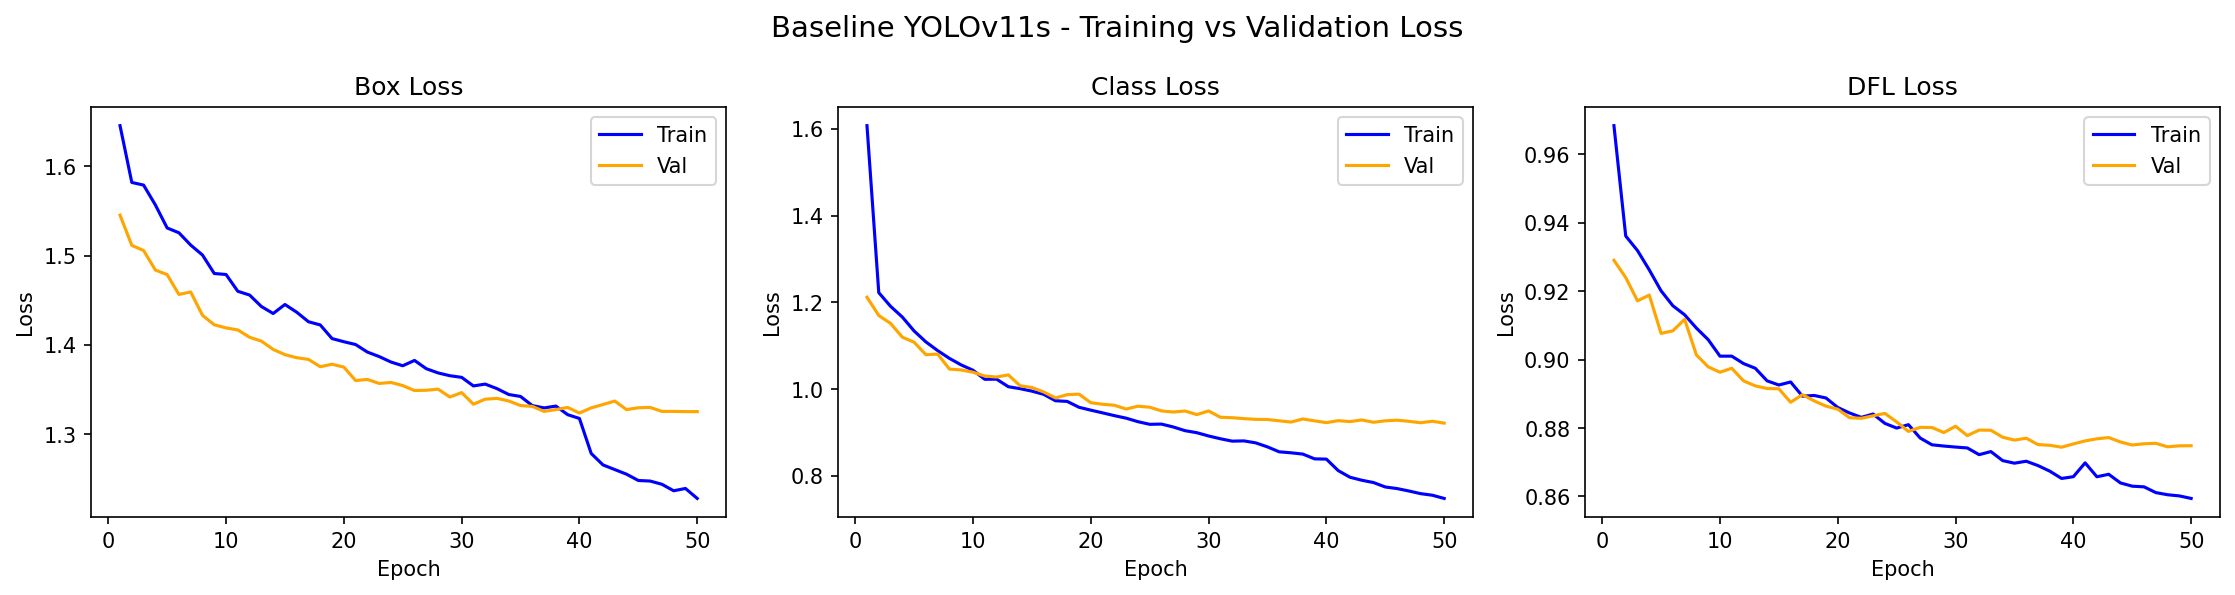

Loss curves saved


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

# Load results
df = pd.read_csv('../experiments/results/baseline_yolo11s/results.csv')
df.columns = df.columns.str.strip()

# Plot for training vs validation loss
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Baseline YOLOv11s - Training vs Validation Loss', fontsize=14)

# Box Loss
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train', color='blue')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val', color='orange')
axes[0].set_title('Box Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Class Loss
axes[1].plot(df['epoch'], df['train/cls_loss'], label='Train', color='blue')
axes[1].plot(df['epoch'], df['val/cls_loss'], label='Val', color='orange')
axes[1].set_title('Class Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

# DFL Loss
axes[2].plot(df['epoch'], df['train/dfl_loss'], label='Train', color='blue')
axes[2].plot(df['epoch'], df['val/dfl_loss'], label='Val', color='orange')
axes[2].set_title('DFL Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()

plt.tight_layout()
plt.savefig('../experiments/results/baseline_yolo11s/loss_curves.png', bbox_inches='tight')
plt.show()
print("Loss curves saved")

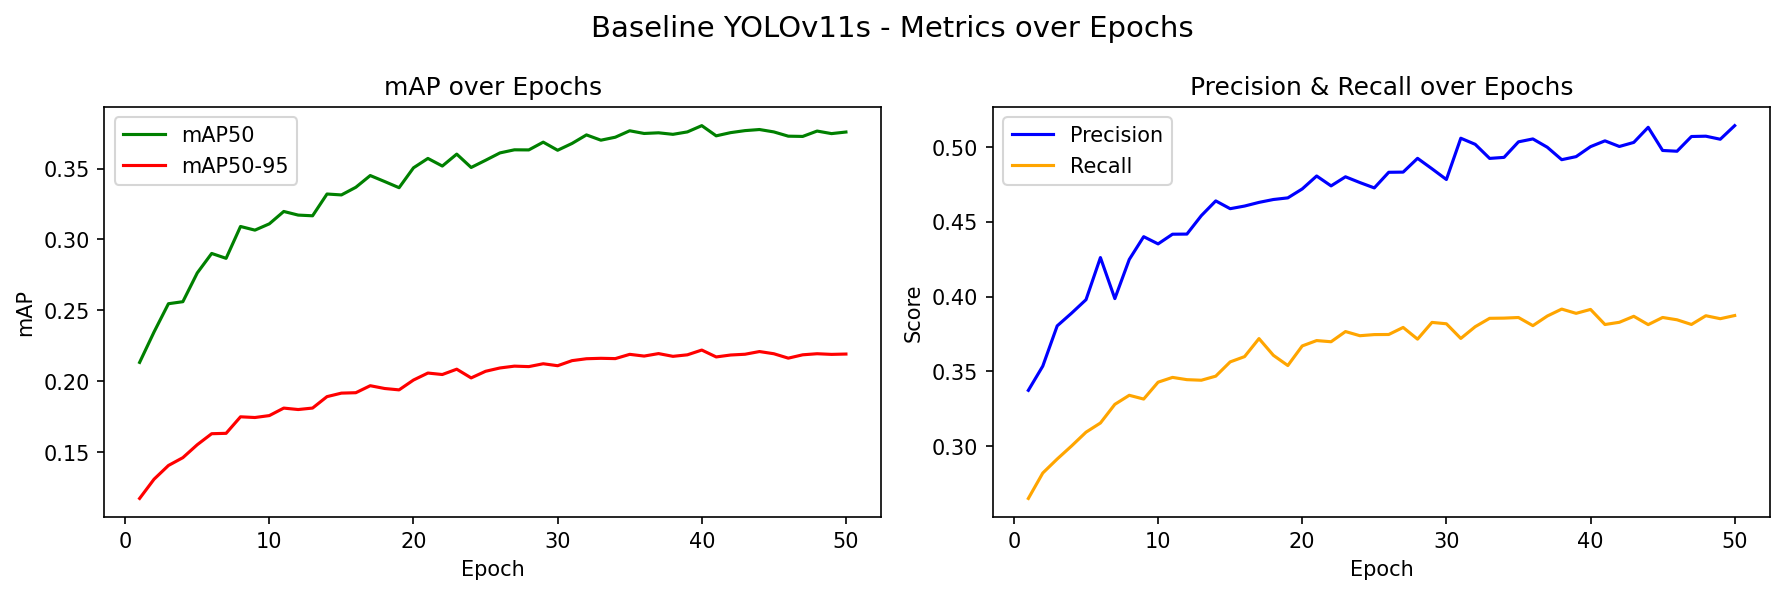

Metrics curves saved


In [9]:
# Plot for mAP and metrics over epochs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Baseline YOLOv11s - Metrics over Epochs', fontsize=14)

# mAP
axes[0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='green')
axes[0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='red')
axes[0].set_title('mAP over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('mAP')
axes[0].legend()

# Precision and Recall
axes[1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='blue')
axes[1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='orange')
axes[1].set_title('Precision & Recall over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../experiments/results/baseline_yolo11s/metrics_curves.png', bbox_inches='tight')
plt.show()
print("Metrics curves saved")

In [10]:
import pandas as pd

# Baseline results
results = {
    'Experiment': [
        'Baseline (YOLOv11s, 640, 50ep)',
        'Exp1 (YOLOv11n, 640, 50ep)',
        'Exp2 (YOLOv11s, 832, 50ep)',
        'Exp3 (YOLOv11m, 640, 50ep)',
        'Exp4 Improvement (YOLOv11m, 832, 100ep)',
    ],
    'mAP50': [0.376, 0.298, 0.446, 0.445, 0.508],
    'mAP50-95': [0.219, 0.166, 0.268, 0.266, 0.310],
    'Precision': [0.514, 0.421, 0.568, 0.576, 0.594],
    'Recall': [0.387, 0.326, 0.439, 0.449, 0.511],
    'Model Size': ['YOLOv11s', 'YOLOv11n', 'YOLOv11s', 'YOLOv11m', 'YOLOv11m'],
    'Image Size': [640, 640, 832, 640, 832],
    'Epochs': [50, 50, 50, 50, 100],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

                             Experiment  mAP50  mAP50-95  Precision  Recall Model Size  Image Size  Epochs
         Baseline (YOLOv11s, 640, 50ep)  0.376     0.219      0.514   0.387   YOLOv11s         640      50
             Exp1 (YOLOv11n, 640, 50ep)  0.298     0.166      0.421   0.326   YOLOv11n         640      50
             Exp2 (YOLOv11s, 832, 50ep)  0.446     0.268      0.568   0.439   YOLOv11s         832      50
             Exp3 (YOLOv11m, 640, 50ep)  0.445     0.266      0.576   0.449   YOLOv11m         640      50
Exp4 Improvement (YOLOv11m, 832, 100ep)  0.508     0.310      0.594   0.511   YOLOv11m         832     100


In [11]:
# Multi-Version YOLO Comparison Table
comparison_data = {
    'Model': [
        'YOLOv5su',
        'YOLOv8s',
        'YOLOv9s',
        'YOLOv10s',
        'YOLOv11s (Baseline)',
        'YOLOv11m (Best)',
    ],
    'mAP50': [0.365, 0.380, 0.379, 0.378, 0.376, 0.508],
    'mAP50-95': [0.211, 0.219, 0.219, 0.220, 0.219, 0.310],
    'Precision': [0.502, 0.519, 0.522, 0.502, 0.514, 0.594],
    'Recall': [0.376, 0.388, 0.381, 0.390, 0.387, 0.511],
    'Parameters (M)': [9.1, 11.1, 7.2, 7.2, 9.4, 20.0],
    'Inference (ms/img)': [4.2, 0.6, 6.0, 0.4, 5.5, 1.5],
    'Image Size': [640, 640, 640, 640, 640, 832],
    'Epochs': [50, 50, 50, 50, 50, 100],
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

              Model  mAP50  mAP50-95  Precision  Recall  Parameters (M)  Inference (ms/img)  Image Size  Epochs
           YOLOv5su  0.365     0.211      0.502   0.376             9.1                 4.2         640      50
            YOLOv8s  0.380     0.219      0.519   0.388            11.1                 0.6         640      50
            YOLOv9s  0.379     0.219      0.522   0.381             7.2                 6.0         640      50
           YOLOv10s  0.378     0.220      0.502   0.390             7.2                 0.4         640      50
YOLOv11s (Baseline)  0.376     0.219      0.514   0.387             9.4                 5.5         640      50
    YOLOv11m (Best)  0.508     0.310      0.594   0.511            20.0                 1.5         832     100


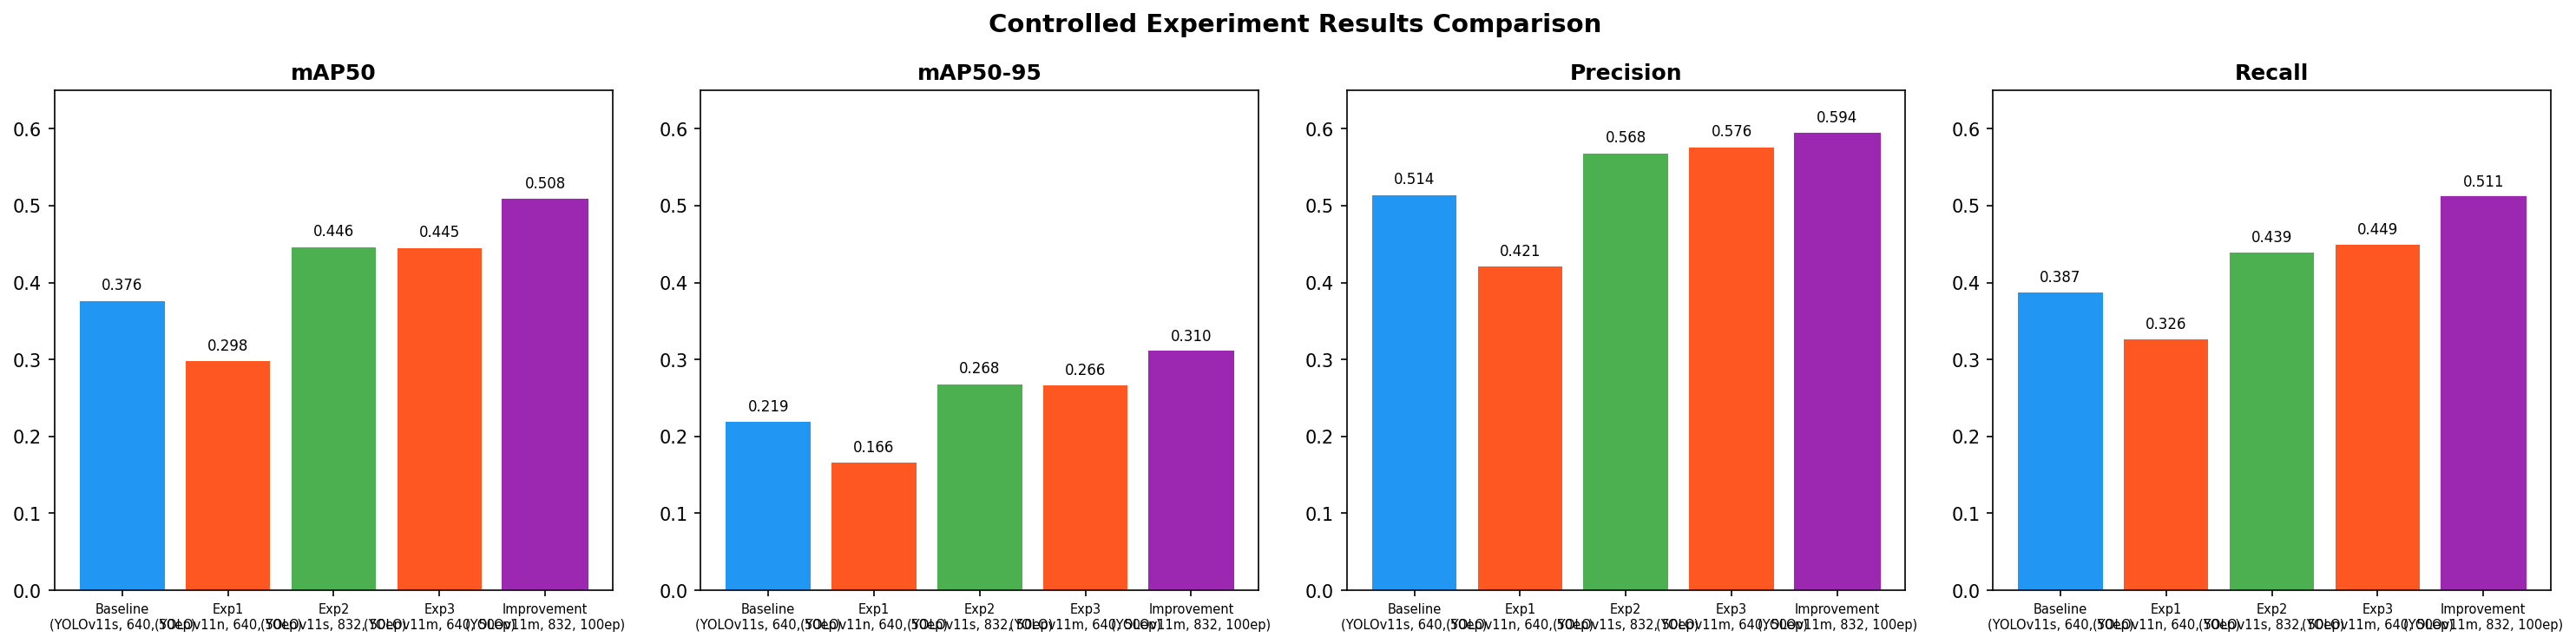

Experiment comparison plot saved


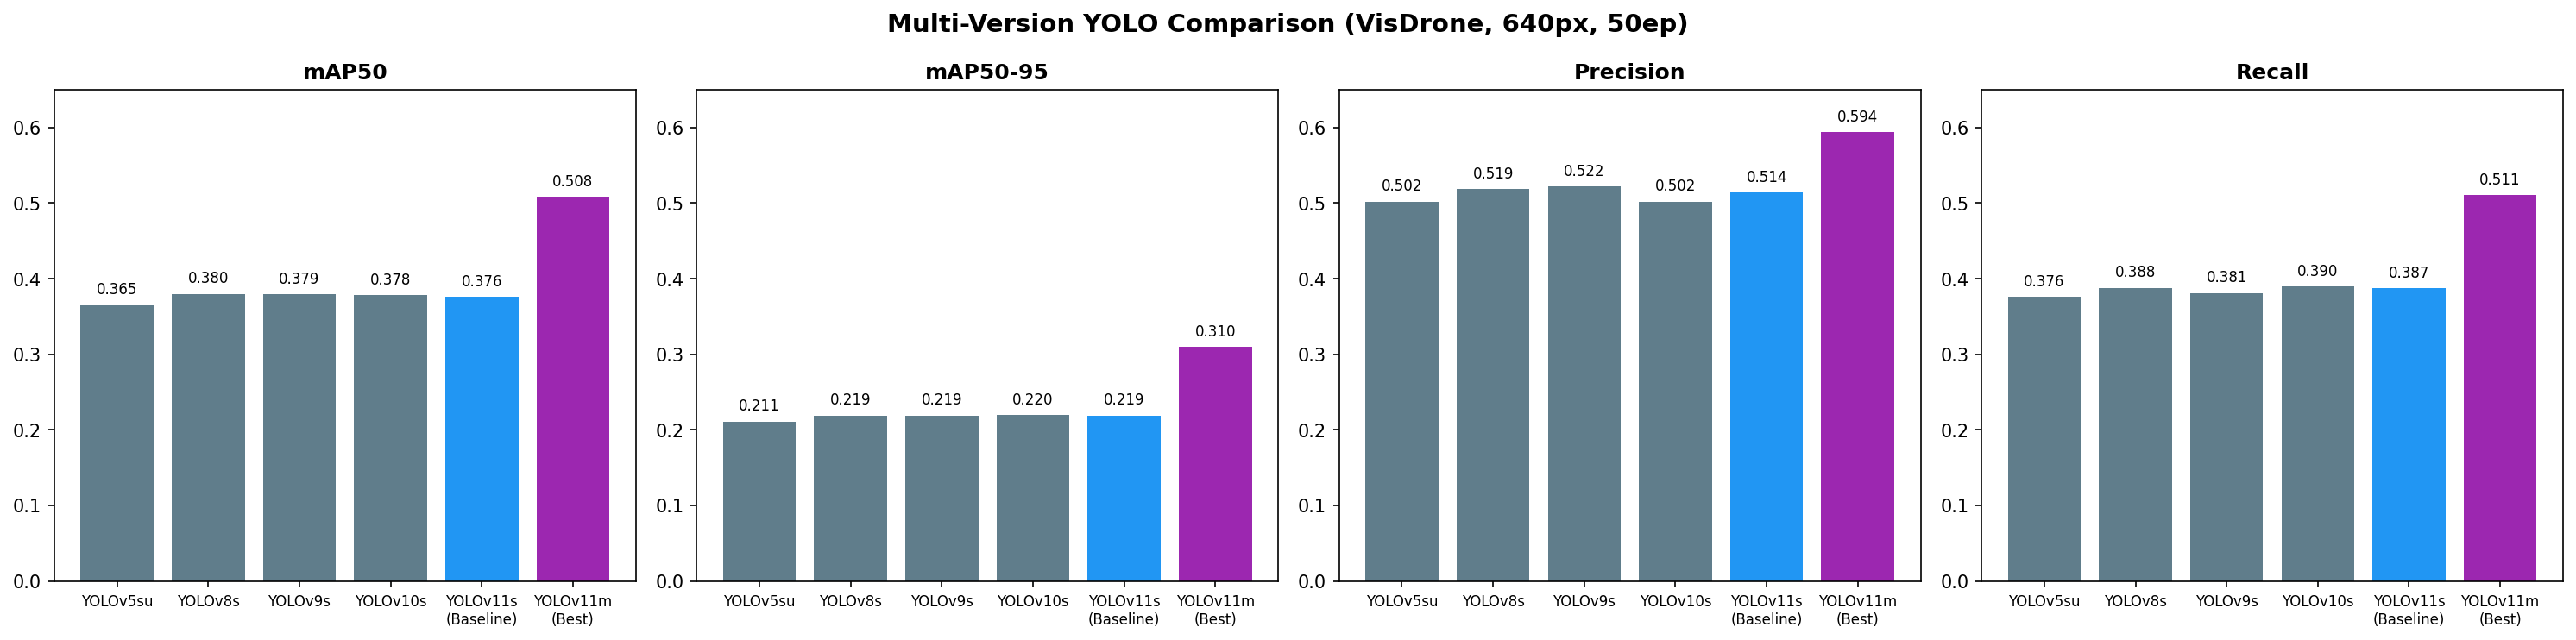

Version comparison plot saved


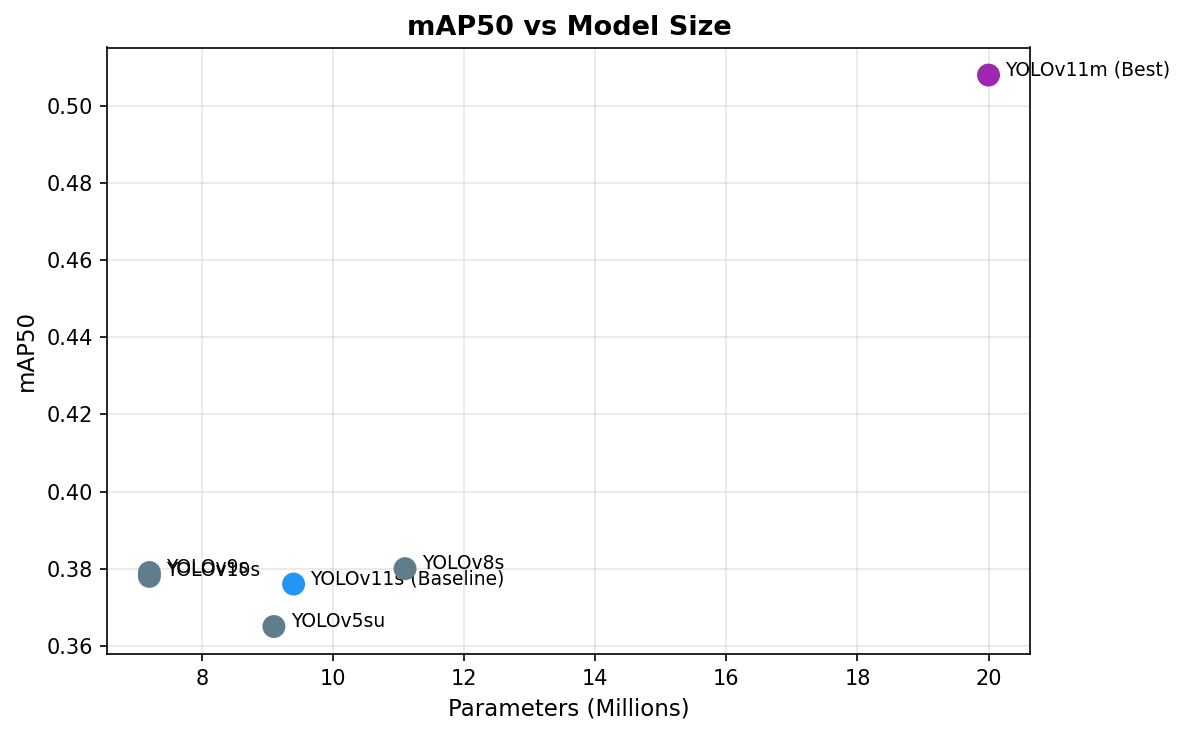

mAP vs params plot saved


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# All Experiment Results
# ============================================================
experiments = {
    'Experiment': [
        'Baseline\n(YOLOv11s, 640, 50ep)',
        'Exp1\n(YOLOv11n, 640, 50ep)',
        'Exp2\n(YOLOv11s, 832, 50ep)',
        'Exp3\n(YOLOv11m, 640, 50ep)',
        'Improvement\n(YOLOv11m, 832, 100ep)',
    ],
    'mAP50': [0.376, 0.298, 0.446, 0.445, 0.508],
    'mAP50-95': [0.219, 0.166, 0.268, 0.266, 0.310],
    'Precision': [0.514, 0.421, 0.568, 0.576, 0.594],
    'Recall': [0.387, 0.326, 0.439, 0.449, 0.511],
}

df_exp = pd.DataFrame(experiments)

# ============================================================
# Plot 1 - Experiment Comparison Bar Chart
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Controlled Experiment Results Comparison', fontsize=14, fontweight='bold')

metrics = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
colors = ['#2196F3', '#FF5722', '#4CAF50', '#FF5722', '#9C27B0']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(range(len(df_exp)), df_exp[metric], color=colors)
    bars[-1].set_color('#9C27B0')  # highlight improvement in purple
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xticks(range(len(df_exp)))
    axes[i].set_xticklabels(df_exp['Experiment'], fontsize=7)
    axes[i].set_ylim(0, 0.65)
    for bar, val in zip(bars, df_exp[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../experiments/results/experiment_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Experiment comparison plot saved")

# ============================================================
# Multi-Version YOLO Comparison
# ============================================================
comparison = {
    'Model': ['YOLOv5su', 'YOLOv8s', 'YOLOv9s', 'YOLOv10s', 'YOLOv11s\n(Baseline)', 'YOLOv11m\n(Best)'],
    'mAP50': [0.365, 0.380, 0.379, 0.378, 0.376, 0.508],
    'mAP50-95': [0.211, 0.219, 0.219, 0.220, 0.219, 0.310],
    'Precision': [0.502, 0.519, 0.522, 0.502, 0.514, 0.594],
    'Recall': [0.376, 0.388, 0.381, 0.390, 0.387, 0.511],
    'Params_M': [9.1, 11.1, 7.2, 7.2, 9.4, 20.0],
}

df_comp = pd.DataFrame(comparison)

# Plot 2 - Multi-Version Comparison Bar Chart
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Multi-Version YOLO Comparison (VisDrone, 640px, 50ep)', fontsize=14, fontweight='bold')

colors_comp = ['#607D8B', '#607D8B', '#607D8B', '#607D8B', '#2196F3', '#9C27B0']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(range(len(df_comp)), df_comp[metric], color=colors_comp)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xticks(range(len(df_comp)))
    axes[i].set_xticklabels(df_comp['Model'], fontsize=8)
    axes[i].set_ylim(0, 0.65)
    for bar, val in zip(bars, df_comp[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../experiments/results/version_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Version comparison plot saved")

# ============================================================
# Plot 3 - mAP50 vs Parameters scatter
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_comp['Params_M'], df_comp['mAP50'], s=100, 
           color=colors_comp, zorder=5)

for i, row in df_comp.iterrows():
    ax.annotate(row['Model'].replace('\n', ' '), 
                (row['Params_M'], row['mAP50']),
                textcoords="offset points", xytext=(8, 0), fontsize=9)

ax.set_xlabel('Parameters (Millions)', fontsize=11)
ax.set_ylabel('mAP50', fontsize=11)
ax.set_title('mAP50 vs Model Size', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../experiments/results/map_vs_params.png', bbox_inches='tight', dpi=150)
plt.show()
print("mAP vs params plot saved")